# 05 · Profiling and tuning one GPU

Phase 4 found the break: at 384 users, vLLM capped running requests at 256 and everything else queued, while the KV cache was only half full. This phase asks **what the engine settings should be for this GPU**, testing one change at a time against the baseline, then profiles where the GPU's time goes, and sets SLOs.

Why the defaults are worth questioning: vLLM 0.30.0 picks its batch limits by GPU memory. GPUs with 70 GB or more get up to 1,024 sequences and 8,192 tokens per scheduler step. Anything smaller, like this 32 GB RTX 5090, falls through to a branch marked *"TODO: Tune the default values for other hardware"*: **256 sequences and 2,048 tokens**.

All numbers are read from `results/05_profiling_and_tuning/`.

## Method

* Every config in `vllm/configs/tune_*.yaml` is the baseline plus **one** change.
* Each runs the Phase 4 Locust load (same mix, unique tags, closed loop) at **64, 128, 192, 256, 384, 512 and 768 users, 45 s per step** (first 10 s of each skipped), on the same machine, in one session, with the baseline rerun first.
* Speculative decoding helps single requests and usually hurts big batches, so it has its own **low load sweep** (1, 4, 16, 64 users) against the baseline.
* The baseline is profiled with PyTorch's profiler for 60 engine steps at 128 users.

In [1]:
import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = ROOT / "results" / "05_profiling_and_tuning"
sys.path.insert(0, str(ROOT / "loadtest"))
from results_logger import load_runs

runs = load_runs("05_profiling_and_tuning")
sweeps = {r["config"]["label"]: r for r in runs if r["name"].startswith("load_sweep_")}
summary = next((r for r in reversed(runs) if r["name"] == "tuning_summary"), None)
profile = next((r for r in reversed(runs) if r["name"].startswith("profile_")), None)
tuning = [k for k in sweeps if not k.startswith(("latency_", "profile_"))]
print(f"tuning sweeps: {tuning}")
print(f"latency sweeps: {[k for k in sweeps if k.startswith('latency_')]} | profile: {bool(profile)}")

tuning sweeps: ['baseline', 'tune_max_num_seqs_512', 'tune_max_num_seqs_1024', 'tune_batched_tokens_8192', 'tune_no_prefix_caching', 'tune_kv_cache_fp8', 'tune_fp8_weights', 'tuned']
latency sweeps: ['latency_baseline', 'latency_tune_ngram_speculative'] | profile: True


## What each config changes

In [2]:
BASE = yaml.safe_load((ROOT / "vllm" / "configs" / "baseline.yaml").read_text())
for name in tuning:
    f = ROOT / "vllm" / "configs" / f"{name}.yaml"
    if f.exists():
        cfg = yaml.safe_load(f.read_text())
        change = {k: v for k, v in cfg.items() if BASE.get(k) != v}
        print(f"{name:<28}{change if change else '(the baseline)'}")

baseline                    (the baseline)
tune_max_num_seqs_512       {'max-num-seqs': 512}
tune_max_num_seqs_1024      {'max-num-seqs': 1024}
tune_batched_tokens_8192    {'max-num-batched-tokens': 8192}
tune_no_prefix_caching      {'enable-prefix-caching': False}
tune_kv_cache_fp8           {'kv-cache-dtype': 'fp8'}
tune_fp8_weights            {'quantization': 'fp8'}
tuned                       {'quantization': 'fp8', 'kv-cache-dtype': 'fp8', 'max-num-seqs': 512}


### What vLLM reported at startup

Some changes alter memory: FP8 weights halve the model's size, an FP8 KV cache halves the bytes per token. Both leave more room for KV cache.

In [3]:
def startup(name):
    f = RESULTS / f"vllm_startup_{name}.log"
    if not f.exists():
        return {}
    text = f.read_text()
    grab = lambda p: (m.group(1) if (m := re.search(p, text)) else None)
    return {"weights": grab(r"Model loading took ([\d.]+ GiB)"), "kv_memory": grab(r"Available KV cache memory: ([\d.]+ GiB)"),
            "kv_tokens": grab(r"GPU KV cache size: ([\d,]+) tokens")}

print(f"{'config':<28}{'weights':>12}{'KV memory':>12}{'KV tokens':>12}")
for name in tuning + ["tune_ngram_speculative"]:
    s = startup(name)
    if s:
        print(f"{name:<28}{s['weights'] or '-':>12}{s['kv_memory'] or '-':>12}{s['kv_tokens'] or '-':>12}")
for f in sorted(RESULTS.glob("failed_*.log")):
    print(f"FAILED TO START: {f.stem.replace('failed_', '')} (see {f.name})")

config                           weights   KV memory   KV tokens
baseline                       14.29 GiB   11.19 GiB     209,472
tune_max_num_seqs_512          14.29 GiB   10.97 GiB     205,488
tune_max_num_seqs_1024         14.29 GiB   10.65 GiB     199,344
tune_batched_tokens_8192       14.29 GiB   11.11 GiB     207,936
tune_no_prefix_caching         14.29 GiB   11.19 GiB     209,472
tune_kv_cache_fp8              14.29 GiB    10.8 GiB     404,480
tune_fp8_weights                8.17 GiB   17.29 GiB     323,824
tuned                           8.17 GiB   16.69 GiB     625,184
tune_ngram_speculative         14.29 GiB    11.2 GiB     209,632


## Every config against the baseline

In [4]:
def cell(value, fmt, width, scale=1, unit=""):
    return ("-" if value is None else format(value * scale, fmt) + unit).rjust(width)

if summary:
    rows = summary["metrics"]["configs"]
    base = next((r for r in rows if r["label"] == "baseline"), None)
    print(f"{'config':<28}{'peak tok/s':>11}{'vs base':>9}{'TTFT p95 @256':>15}{'TTFT p95 @512':>15}{'ITL p50 @256':>14}"
          f"{'max running':>13}{'KV max':>8}{'preempt':>9}")
    for r in rows:
        a, b = r["at_users"].get(256, {}), r["at_users"].get(512, {})
        vs = f"{r['peak_output_tokens_per_s'] / base['peak_output_tokens_per_s'] - 1:+.0%}" if base and r["peak_output_tokens_per_s"] else ""
        print(f"{r['label']:<28}{cell(r['peak_output_tokens_per_s'], '.0f', 11)}{vs:>9}"
              f"{cell(a.get('ttft_p95_s'), '.0f', 15, 1000, 'ms')}{cell(b.get('ttft_p95_s'), '.0f', 15, 1000, 'ms')}"
              f"{cell(a.get('itl_p50_s'), '.1f', 14, 1000, 'ms')}{cell(r['max_running'], '.0f', 13)}"
              f"{cell(r['max_kv_cache_usage'], '.0%', 8)}{cell(r['preemptions'], '.0f', 9)}")
else:
    print("No tuning summary yet: run scripts/run_phase5.sh on the GPU box, then copy results/ back.")

config                       peak tok/s  vs base  TTFT p95 @256  TTFT p95 @512  ITL p50 @256  max running  KV max  preempt
baseline                           5794      +0%              -              -             -          256     57%        0
tune_max_num_seqs_512              6013      +4%              -              -             -          510    100%      238
tune_max_num_seqs_1024             5835      +1%              -              -             -          508    100%      348
tune_batched_tokens_8192           5949      +3%              -              -             -          256     55%        0
tune_no_prefix_caching             5942      +3%              -              -             -          256     56%        0
tune_kv_cache_fp8                  7064     +22%              -              -             -          256     30%        0
tune_fp8_weights                   8662     +50%              -              -             -          256     35%        0
tuned           

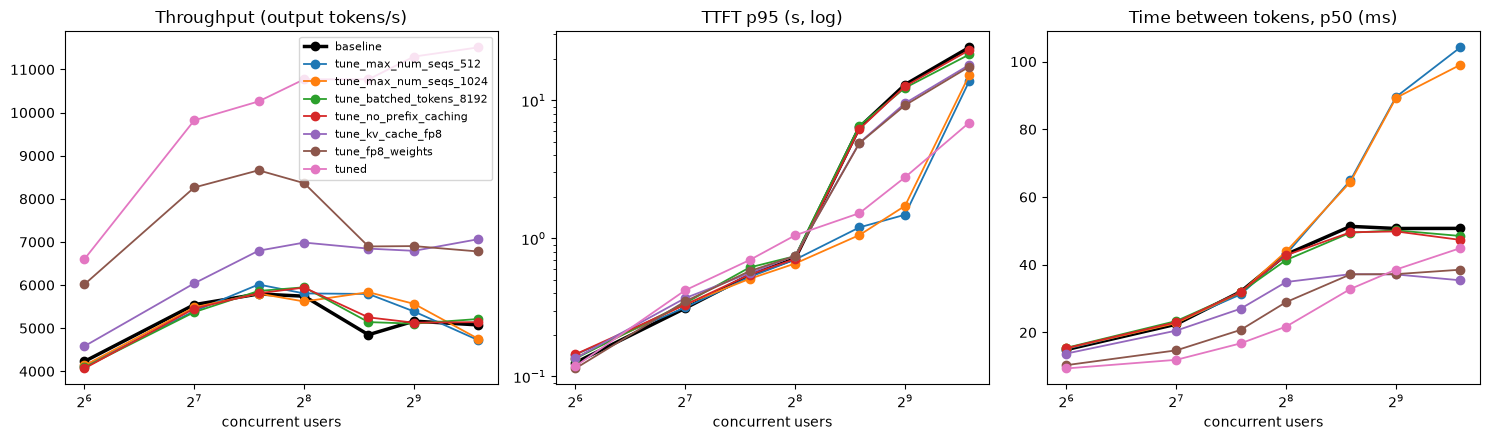

In [5]:
if tuning:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for name in tuning:
        steps = sweeps[name]["metrics"]["steps"]
        users = [s["users"] for s in steps]
        style = dict(marker="o", lw=2.5 if name == "baseline" else 1.3, color="black" if name == "baseline" else None)
        axes[0].plot(users, [s.get("server", {}).get("output_tokens_per_s") for s in steps], label=name, **style)
        axes[1].plot(users, [s["ttft_s"]["p95"] for s in steps], label=name, **style)
        axes[2].plot(users, [s["itl_s"]["p50"] and s["itl_s"]["p50"] * 1000 for s in steps], label=name, **style)
    axes[0].set_title("Throughput (output tokens/s)")
    axes[1].set_title("TTFT p95 (s, log)"); axes[1].set_yscale("log")
    axes[2].set_title("Time between tokens, p50 (ms)")
    for ax in axes:
        ax.set_xscale("log", base=2); ax.set_xlabel("concurrent users")
    axes[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Capacity and cost per target

Two service level targets, applied to every config:

* **interactive**: TTFT p95 ≤ 0.5 s and ITL p50 ≤ 40 ms (at least 25 tokens/s per user)
* **relaxed**: TTFT p95 ≤ 1 s and ITL p50 ≤ 60 ms (at least 16 tokens/s per user)

Capacity is the highest user count in the sweep that meets the target; cost is the GPU's hourly price divided by the output tokens it produces per hour at that load.

In [6]:
if summary:
    price = summary["config"]["price_per_hour_usd"]
    print(f"GPU price: ${price}/hour\n")
    print(f"{'config':<28}{'interactive users':>18}{'tok/s':>8}{'$/1M':>8}{'relaxed users':>15}{'tok/s':>8}{'$/1M':>8}")
    for r in summary["metrics"]["configs"]:
        i, x = r["capacity"]["interactive"], r["capacity"]["relaxed"]
        print(f"{r['label']:<28}{i['users']:>18}{cell(i['output_tokens_per_s'], '.0f', 8)}{cell(i['usd_per_million_output_tokens'], '.3f', 8)}"
              f"{x['users']:>15}{cell(x['output_tokens_per_s'], '.0f', 8)}{cell(x['usd_per_million_output_tokens'], '.3f', 8)}")

GPU price: $1.327/hour

config                       interactive users   tok/s    $/1M  relaxed users   tok/s    $/1M
baseline                                   128    5546   0.066            256    5742   0.064
tune_max_num_seqs_512                      128    5395   0.068            256    5806   0.063
tune_max_num_seqs_1024                     128    5484   0.067            256    5619   0.066
tune_batched_tokens_8192                   128    5372   0.069            256    5949   0.062
tune_no_prefix_caching                     128    5456   0.068            256    5942   0.062
tune_kv_cache_fp8                          128    6041   0.061            256    6986   0.053
tune_fp8_weights                           128    8264   0.045            256    8363   0.044
tuned                                      128    9821   0.038            192   10259   0.036


## Speculative decoding at low load

N-gram speculation guesses the next few tokens by copying from the prompt and lets the model verify them in one step. It can't add GPU throughput, but when the GPU is idle between single requests it can make each answer stream faster.

In [7]:
pair = [k for k in ("latency_baseline", "latency_tune_ngram_speculative") if k in sweeps]
if len(pair) == 2:
    print(f"{'users':>6}" + "".join(f"{p.replace('latency_', ''):>40}" for p in pair))
    print(f"{'':>6}" + "".join(f"{'TTFT p50   ITL p50   e2e p50   tok/s':>40}" for _ in pair))
    by = {p: {s["users"]: s for s in sweeps[p]["metrics"]["steps"]} for p in pair}
    for u in sorted(by[pair[0]]):
        line = f"{u:>6}"
        for p in pair:
            s = by[p].get(u)
            line += (f"{cell(s['ttft_s']['p50'], '.0f', 10, 1000, 'ms')}{cell(s['itl_s']['p50'], '.1f', 10, 1000, 'ms')}"
                     f"{cell(s['e2e_s']['p50'], '.2f', 10, 1, 's')}{cell(s.get('server', {}).get('output_tokens_per_s'), '.0f', 10)}") if s else " " * 40
        print(line)
    print("\nend to end p95 by request type (baseline -> speculative):")
    for u in sorted(by[pair[0]]):
        cats = sorted(by[pair[0]][u]["by_category"])
        print(f"{u:>6} users  " + "   ".join(
            f"{c}: {by[pair[0]][u]['by_category'][c]['e2e_p95_s']:.2f}s -> {by[pair[1]][u]['by_category'].get(c, {}).get('e2e_p95_s') or float('nan'):.2f}s"
            for c in cats))
else:
    print("No latency sweeps yet.")

 users                                baseline                  tune_ngram_speculative
          TTFT p50   ITL p50   e2e p50   tok/s    TTFT p50   ITL p50   e2e p50   tok/s
     1      26ms     9.7ms     0.64s       102         -         -         -         0
     4      39ms     9.9ms     1.72s       395      29ms    11.7ms     1.63s       298
    16      45ms    11.4ms     2.27s      1369      41ms    13.5ms     2.82s      1202
    64      66ms    14.9ms     2.38s      4250      75ms    23.3ms     3.13s      2757

end to end p95 by request type (baseline -> speculative):
     1 users  long_generation: 7.51s -> nans   multi_turn: 3.01s -> nans   short_qa: 0.64s -> nans   summarization: 3.70s -> nans
     4 users  long_generation: 7.82s -> 9.04s   multi_turn: 2.77s -> 3.07s   short_qa: 0.67s -> 0.80s   summarization: 3.96s -> 4.19s
    16 users  long_generation: 10.11s -> 17.32s   multi_turn: 3.23s -> 3.68s   short_qa: 0.78s -> 0.93s   summarization: 4.77s -> 5.81s
    64 users  long_

## Profile: where the GPU's time goes

60 engine steps of the baseline at 128 concurrent users, from vLLM's PyTorch profiler (`loadtest/analyze_profile.py`).

24,306 GPU kernels over 1310 ms; GPU busy 98% of that time

  matmul (GEMM)           934.8 ms   73.0%
  attention               302.8 ms   23.6%
  activation               10.6 ms    0.8%
  normalization            10.3 ms    0.8%
  memory and copies        10.1 ms    0.8%
  sampling                  9.1 ms    0.7%
  other                     3.7 ms    0.3%

top kernels:
   63.6%  matmul (GEMM)      void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_128x64_64x3_tn_align8>
   16.0%  attention          void flash::flash_fwd_splitkv_kernel<Flash_fwd_kernel_traits<128, 64, 128, 4, false, false
    7.4%  attention          void flash::flash_fwd_splitkv_kernel<Flash_fwd_kernel_traits<128, 64, 64, 4, false, false,
    4.3%  matmul (GEMM)      void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_128x128_32x4_tn_align8
    2.8%  matmul (GEMM)      void cutlass::Kernel2<cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_64x256_32x4_tn_align8>
    1.4%  matmul (GEMM)  

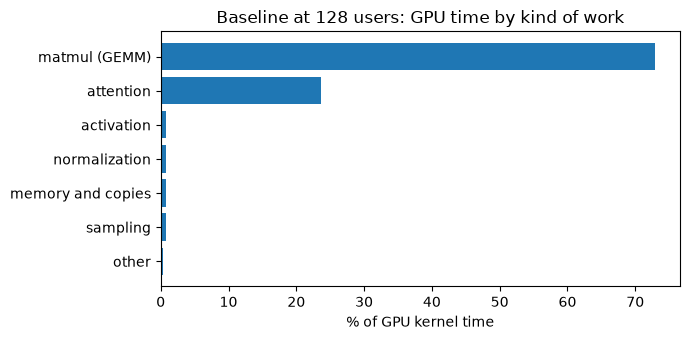

In [8]:
if profile and profile["metrics"].get("kernels"):
    m = profile["metrics"]
    print(f"{m['kernels']:,} GPU kernels over {m['window_ms']:.0f} ms; GPU busy {m['gpu_busy_ratio']:.0%} of that time\n")
    for c, v in m["by_category"].items():
        print(f"  {c:<20}{v['ms']:>9.1f} ms  {v['share']:>6.1%}")
    print("\ntop kernels:")
    for k in m["top_kernels"][:10]:
        print(f"  {k['share']:>6.1%}  {k['category']:<18} {k['name'][:90]}")
    fig, ax = plt.subplots(figsize=(7, 3.5))
    cats = list(m["by_category"])
    ax.barh(cats, [m["by_category"][c]["share"] * 100 for c in cats])
    ax.invert_yaxis(); ax.set_xlabel("% of GPU kernel time"); ax.set_title("Baseline at 128 users: GPU time by kind of work")
    plt.tight_layout(); plt.show()
else:
    print("No profile yet.")

## The combined config, and the quality check

`vllm/configs/tuned.yaml` combined the winners: FP8 weights + FP8 KV cache + max-num-seqs 512. It ran through the same sweep, and the 22-case eval set from Phase 3 ran on the baseline and on it. Quality failed, so the eval set was then run on each FP8 change alone to find the cause.

In [9]:
if "tuned" in sweeps:
    print(f"{'users':>6}{'tok/s':>8}{'TTFT p95':>11}{'ITL p50':>10}{'running':>9}{'waiting':>9}{'KV max':>8}")
    for s in sweeps["tuned"]["metrics"]["steps"]:
        sv = s.get("server", {})
        print(f"{s['users']:>6}{cell(sv.get('output_tokens_per_s'), '.0f', 8)}{cell(s['ttft_s']['p95'], '.0f', 11, 1000, 'ms')}"
              f"{cell(s['itl_s']['p50'], '.1f', 10, 1000, 'ms')}{cell((sv.get('running') or {}).get('avg'), '.0f', 9)}"
              f"{cell((sv.get('waiting') or {}).get('max'), '.0f', 9)}{cell((sv.get('kv_cache_usage') or {}).get('max'), '.0%', 8)}")

 users   tok/s   TTFT p95   ITL p50  running  waiting  KV max
    64    6602      118ms     9.4ms       63        0      5%
   128    9821      421ms    11.9ms      112        0      9%
   192   10259      696ms    16.8ms      162       12     14%
   256   10773     1052ms    21.7ms      226       13     18%
   384   10771     1523ms    32.8ms      331        0     27%
   512   11300     2770ms    38.6ms      444       11     36%
   768   11513     6902ms    44.9ms      496      215     40%


In [10]:
quality = {r["config"]["label"]: r for r in runs if r["name"].startswith("evals_quality_")}
peak = {r["label"]: r["peak_output_tokens_per_s"] for r in summary["metrics"]["configs"]} if summary else {}
if quality:
    base = {c["id"]: c["result"]["content"] for c in quality["quality_baseline"]["metrics"]["cases"]}
    order = ["quality_baseline", "quality_tune_fp8_weights", "quality_tune_kv_cache_fp8", "quality_tuned"]
    print(f"{'config':<22}{'passed':>8}{'same answer as BF16':>21}{'peak tok/s':>12}   by category")
    for l in [o for o in order if o in quality]:
        r = quality[l]["metrics"]
        same = sum(base[c["id"]] == c["result"]["content"] for c in r["cases"])
        name = l.replace("quality_", "")
        print(f"{name:<22}{r['summary']['passed']:>5}/{r['summary']['total']}{same:>18}/22{cell(peak.get(name), '.0f', 12)}   "
              + ", ".join(f"{k} {v['passed']}/{v['total']}" for k, v in r["summary"]["by_category"].items()))

config                  passed  same answer as BF16  peak tok/s   by category
baseline                 21/22                22/22        5794   correctness 7/7, instructions 5/5, summarization 0/1, safety 3/3, harness 6/6
tune_fp8_weights         21/22                14/22        8662   correctness 7/7, instructions 5/5, summarization 0/1, safety 3/3, harness 6/6
tune_kv_cache_fp8        17/22                 7/22        7064   correctness 4/7, instructions 4/5, summarization 0/1, safety 3/3, harness 6/6
tuned                    15/22                 6/22       11513   correctness 4/7, instructions 3/5, summarization 0/1, safety 2/3, harness 6/6


### What the FP8 KV cache did to the answers

In [11]:
if quality:
    by_id = {l: {c["id"]: c for c in quality[l]["metrics"]["cases"]} for l in quality}
    for cid in ["correct_arithmetic", "correct_boiling_f", "correct_http_429", "format_json", "summary_incident"]:
        print(f"{cid}")
        for l in ["quality_baseline", "quality_tune_fp8_weights", "quality_tune_kv_cache_fp8"]:
            c = by_id[l][cid]
            print(f"   {l.replace('quality_', ''):<20}{'PASS' if c['passed'] else 'FAIL'}  {c['result']['content'][:90]!r}")
        print()

correct_arithmetic
   baseline            PASS  '391'
   tune_fp8_weights    PASS  '391'
   tune_kv_cache_fp8   FAIL  '253'

correct_boiling_f
   baseline            PASS  '212'
   tune_fp8_weights    PASS  '212'
   tune_kv_cache_fp8   FAIL  '239'

correct_http_429
   baseline            PASS  'Too Many Requests'
   tune_fp8_weights    PASS  'Too Many Requests'
   tune_kv_cache_fp8   FAIL  '40 0 incorrect.'

format_json
   baseline            PASS  '```json\n{\n  "name": "Alice",\n  "age": 30\n}\n```'
   tune_fp8_weights    PASS  '```json\n{\n  "name": "Alice",\n  "age": 30\n}\n```'
   tune_kv_cache_fp8   FAIL  '```json\n{\n\n{"name": "Alice", "age": 3}\n \n```'

summary_incident
   baseline            FAIL  '- At 09:12 UTC on Tuesday, the payments API experienced elevated error rates and increased'
   tune_fp8_weights    FAIL  '- At 09:12 UTC on Tuesday, the payments API experienced elevated error rates and increased'
   tune_kv_cache_fp8   FAIL  '- ** the payments API began elevated 

## Grafana

No dashboard screenshots were taken in this session; every number above comes from the saved results.

## What happened

**1. The GPU is busy, and busy with the weights.** The profile at 128 users shows the GPU running kernels 98% of the time, 73% of it on matrix multiplies against the model weights and 24% on attention. One BF16 matrix multiply kernel alone was 64% of GPU time.

**2. FP8 weights is the recommended change: +50% throughput with no loss of quality.** Peak output went from 5,794 to 8,662 tokens/s, time between tokens fell by about a third at every load, KV capacity grew from 209k to 324k tokens, and cost per million output tokens fell from $0.064 to $0.044. On the eval set it passed exactly the cases the BF16 baseline passed (21 of 22); 8 answers were worded differently but still right.

**3. The FP8 KV cache looked like the second best change and is not usable.** +22% throughput and double the KV capacity, but it answered 17 × 23 = "253", 100 °C = "239 °F", produced broken JSON and wrote an incident summary starting "at 992". 17 of 22 evals passed. Storing attention keys and values in FP8 without calibrated scales loses too much precision for this model.

**4. Combining the winners nearly doubled throughput and broke the model.** FP8 weights + FP8 KV cache + 512 sequences reached 11,513 tokens/s (+99%) and passed only 15 of 22 evals, including failing to refuse a phishing request. Without the eval set, this config would have looked like the result of the phase. **Every throughput gain has to be checked against quality.**

**5. Raising the sequence cap trades queueing for slower streaming.** max-num-seqs 512 added only 4% throughput, but at 384 to 512 users cut TTFT p95 from 6 to 13 s down to 1.2 to 1.5 s, while time between tokens rose to 65 to 90 ms. In BF16, the KV cache filled at about 500 running requests and preemptions began.

**6. Batched tokens and prefix caching made no difference on this traffic**, and **n-gram speculative decoding made it worse** (slower tokens at every load, one 59 s request at a single user).

**7. The baseline reproduced across machines.** On a different machine with the same GPU and CPU, it peaked within 3% of Phase 4 and broke at the same user count.

### SLOs and capacity for one RTX 5090 (FP8 weights, priced at $1.327/hr like the earlier phases; this machine's $1.211/hr is 9% less)

| Target | Users | Output tokens/s | Cost per 1M output tokens |
|---|---|---|---|
| Interactive: TTFT p95 ≤ 0.5 s, ITL p50 ≤ 40 ms | 128 | 8,264 | $0.045 |
| Relaxed: TTFT p95 ≤ 1 s, ITL p50 ≤ 60 ms | 256 | 8,363 | $0.044 |

(Capacity is limited to the steps tested; the interactive limit lies somewhere between 128 and 192 users.)

**Next experiments:** FP8 weights with max-num-seqs 512 (FP8 frees enough memory that a higher cap may cut first token times past 256 users without hitting the memory wall); a calibrated FP8 KV cache; and finer steps between 128 and 192 users to pin down interactive capacity.

## Phase 5 exit criteria

- [x] One-change configs for sequences, batch tokens, prefix caching, FP8 KV cache, FP8 weights and speculative decoding
- [x] Same load and machine for every config, with automatic comparison, capacity and cost per target
- [x] Profiler capture and analysis of where GPU time goes
- [x] Phase 5 session on the RTX 5090
- [x] A tuned config (FP8 weights), checked for quality, with the SLOs it meets and the capacity and cost of one GPU